# 03 — Forecasting Revenue + COGS 548 ngày (Phần B)

**Nguồn port:** `docs/analysis/phase7_baseline` (baseline B1/B2/B3/B3b) + Phase 8/9
(`feat/phase8-model`, LightGBM + ensemble + SHAP/robustness — 2 phase này CHƯA
merge vào `docs/analysis` nhánh `chore/restructure-lakehouse`, xem
`.process_status/M4b.md` mục "Nguồn port"). Toàn bộ thuật toán gọi qua module đã
port `src/datathon/{features,models,backtest,submission}.py` (milestone M4b,
commit `f4036f9`) — notebook này **KHÔNG viết lại công thức**, chỉ gọi hàm thật +
trình bày/diễn giải kết quả thật.

**Chạy được:** local (venv project, `.venv/bin/jupyter`) hoặc **Google Colab**
(cell đầu tự clone repo + cài subset dependencies + set data path — không
hardcode path máy local, đọc qua `datathon.config`).

**Business framing:** dự đoán Revenue + COGS (GROSS, đối chiếu `sales.csv`) mỗi
ngày, 548 ngày tương lai (2023-01-01 → 2024-07-01) — Phần B đề bài. **Chưa có
ground-truth thật** → mọi metric backtest trong notebook đến từ holdout nội bộ
2012-2022 (rolling-origin, 5 fold, xem mục 3). Mốc phải vượt: baseline B1
seasonal-naive, WAPE fold chính thức `main_548d` — Revenue **25.18%**, COGS
**23.09%** (`docs/analysis/phase7_baseline/baseline_report.md`).

## Bootstrap môi trường (local hoặc Colab)

Cell dưới: nếu chạy trên Colab → tự `git clone` repo (branch
`chore/restructure-lakehouse`) vào `/content/`; nếu chạy local → tự dò lên
thư mục cha tới khi thấy `pyproject.toml` (chạy được dù mở notebook từ
`notebooks/` hay từ root). Sau đó thêm `src/` vào `sys.path` để `import
datathon` hoạt động mà không cần cài package.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/lhoanghai1912/ML_Learning.git"
BRANCH = "chore/restructure-lakehouse"

if IN_COLAB:
    repo_dir = Path("/content/ML_Learning")
    if not (repo_dir / "pyproject.toml").exists():
        subprocess.run(
            ["git", "clone", "--branch", BRANCH, REPO_URL, str(repo_dir)],
            check=True,
        )
    os.chdir(repo_dir)
else:
    repo_dir = Path.cwd()
    while not (repo_dir / "pyproject.toml").exists() and repo_dir != repo_dir.parent:
        repo_dir = repo_dir.parent
    assert (repo_dir / "pyproject.toml").exists(), (
        "Không tìm thấy pyproject.toml đi lên từ cwd hiện tại — chạy notebook "
        "từ trong repo (local), hoặc IN_COLAB sẽ tự clone."
    )
    os.chdir(repo_dir)

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("PROJECT_ROOT =", PROJECT_ROOT)
print("IN_COLAB =", IN_COLAB)

PROJECT_ROOT = /Users/lhoanghai_/Documents/Study/Dự án datathon2026
IN_COLAB = False


## Cài dependencies (subset `pyproject.toml` — CHỈ phần notebook này cần)

`pyproject.toml` gốc còn khai cả stack hạ tầng (Spark/Trino/dbt/MinIO/Postgres —
`dbt-trino`, `pyiceberg`, `trino`, `psycopg2-binary`, `boto3`, ...) không dùng ở
notebook forecast này → chỉ cài subset dependencies THẬT SỰ được `import` bên
dưới (`datathon.features/models/backtest/submission` + matplotlib để vẽ), để
Colab cài nhanh, không tốn phút chờ cài Spark/dbt không cần thiết.

In [2]:
DEPS = [
    "pandas", "numpy", "matplotlib", "lunardate",
    "scikit-learn", "scipy", "xgboost", "lightgbm",
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *DEPS], check=True)
print("deps OK:", DEPS)

deps OK: ['pandas', 'numpy', 'matplotlib', 'lunardate', 'scikit-learn', 'scipy', 'xgboost', 'lightgbm']


In [3]:
import io
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datathon import config
from datathon import features
from datathon import models
from datathon import backtest
from datathon import submission

print("PROJECT_ROOT (config) =", config.PROJECT_ROOT)
print("RAW_TABLES:", len(config.RAW_TABLES), "bảng")
print("TARGETS:", features.TARGETS)
print("FINAL_CONFIG:", models.FINAL_CONFIG)

PROJECT_ROOT (config) = /Users/lhoanghai_/Documents/Study/Dự án datathon2026
RAW_TABLES: 14 bảng
TARGETS: ['Revenue', 'COGS']
FINAL_CONFIG: {'Revenue': {'tree_model': 'LightGBM', 'use_ensemble': True, 'use_quarter': False}, 'COGS': {'tree_model': 'LightGBM', 'use_ensemble': True, 'use_quarter': False}}


## 0. Data — đọc qua `datathon.config` (0 hardcode path)

`src/datathon/config.py` là nguồn path DUY NHẤT: `RAW_TABLES["sales"]` +
`RAW_TABLES["sample_submission"]` (2 file notebook này cần). Mặc định đọc
`<PROJECT_ROOT>/data/raw/` — override bằng biến môi trường `DATA_RAW_PATH`
(phải set **TRƯỚC** khi `import datathon.config`, hoặc `importlib.reload`
sau khi set như cell dưới).

**Trên Colab** (chưa có nguồn tải public chính thức — xem `data/README.md`
mục 0, PO còn nợ link): 2 cách nạp data trước khi chạy mục 1:
1. Mount Google Drive, đặt 14 CSV vào 1 thư mục Drive, sửa
   `COLAB_DRIVE_DATA_DIR` ở cell dưới.
2. Upload thủ công qua `google.colab.files.upload()` (phiên tạm, ít file).

**Local:** `data/raw/*.csv` đã có sẵn trên máy (xem `data/README.md`) — cell
dưới PASS ngay, không cần làm gì thêm.

In [4]:
# Chỉnh nếu chạy Colab + đã mount Drive chứa 14 CSV raw ở thư mục khác:
COLAB_DRIVE_DATA_DIR = "/content/drive/MyDrive/datathon2026_raw"


def _raw_ready() -> bool:
    return config.RAW_TABLES["sales"].exists() and config.RAW_TABLES["sample_submission"].exists()


if IN_COLAB and not _raw_ready():
    from google.colab import drive

    drive.mount("/content/drive")
    if Path(COLAB_DRIVE_DATA_DIR).exists():
        os.environ["DATA_RAW_PATH"] = COLAB_DRIVE_DATA_DIR
    else:
        print(
            f"KHONG thay {COLAB_DRIVE_DATA_DIR}. Upload thu cong 14 CSV "
            "(xem data/README.md) roi chay lai cell nay, hoac sua COLAB_DRIVE_DATA_DIR."
        )
        try:
            from google.colab import files

            uploaded = files.upload()  # chon 14 CSV cung luc
            upload_dir = Path("/content/data_raw_uploaded")
            upload_dir.mkdir(exist_ok=True)
            for name in uploaded:
                Path(name).rename(upload_dir / name)
            os.environ["DATA_RAW_PATH"] = str(upload_dir)
        except Exception as e:
            print("Upload thu cong bo qua / loi:", e)
    import importlib

    importlib.reload(config)

assert _raw_ready(), (
    f"Thieu data/raw. sales={config.RAW_TABLES['sales']} "
    f"sample_submission={config.RAW_TABLES['sample_submission']}. Xem data/README.md muc 0."
)
print("Data OK - DATA_RAW =", config.DATA_RAW)

Data OK - DATA_RAW = /Users/lhoanghai_/Documents/Study/Dự án datathon2026/data/raw


## 1. Problem framing & baseline

- **Dự đoán:** Revenue + COGS (GROSS) mỗi ngày, 548 ngày tương lai — 2 target
  train **ĐỘC LẬP** (không dùng target này dự đoán target kia).
- **Business metric chính:** WAPE (Weighted Absolute Percentage Error) — ổn
  định hơn MAPE khi có ngày actual nhỏ (đề bài khuyến nghị).
- **Baseline (mốc phải vượt):** B1 seasonal-naive (ŷ(t) = giá trị đúng ngày
  này năm trước, dung sai ±3 ngày, fallback trung bình lịch sử) — đã thắng cả
  B2 month-mean và B3/B3b linear ở `docs/analysis/phase7_baseline` (linear bias
  ngoại suy `trend_index` +29~39%, xem `baseline_report.md` mục 4.4).
- **Split chống leakage:** rolling-origin 5 fold THEO THỜI GIAN
  (`backtest.build_rolling_folds`) — mỗi fold `train_fit` kết thúc TRƯỚC
  `holdout` bắt đầu (không overlap). Fold `main_548d` (548 ngày cuối,
  2021-07-02→2022-12-31) là fold CHÍNH THỨC dùng chọn model; 4 fold
  `rolling_*` lùi về quá khứ dùng đánh giá độ ổn định.

## 2. Load feature (calendar + Tết + lag 365) — `datathon.features`

In [5]:
train = features.load_train_features()
forecast_cal = features.load_forecast_features()

print("train:", train.shape, train["Date"].min().date(), "->", train["Date"].max().date())
print("forecast:", forecast_cal.shape, forecast_cal["Date"].min().date(), "->", forecast_cal["Date"].max().date())
assert train[["Revenue", "COGS"]].isna().sum().sum() == 0, "target NaN trong train"
train.head()

train: (3833, 19) 2012-07-04 -> 2022-12-31
forecast: (548, 17) 2023-01-01 -> 2024-07-01


,Date,month,quarter,day_of_week,day_of_month,month_sin,month_cos,dow_sin,dow_cos,is_post_2019,is_post_2019_transition,days_from_tet,is_low_margin_season,trend_index,is_holiday_302_305,is_holiday_qk,is_christmas,Revenue,COGS
0,2012-07-04,7,3,2,4,-0.5,-0.866025,0.974928,-0.222521,0,0,163,1,0,0,0,0,5123547.94,3982991.19
1,2012-07-05,7,3,3,5,-0.5,-0.866025,0.433884,-0.900969,0,0,164,1,1,0,0,0,2751773.45,2150580.23
2,2012-07-06,7,3,4,6,-0.5,-0.866025,-0.433884,-0.900969,0,0,165,1,2,0,0,0,3054029.42,2517632.84
3,2012-07-07,7,3,5,7,-0.5,-0.866025,-0.974928,-0.222521,0,0,166,1,3,0,0,0,2667930.94,2108246.62
4,2012-07-08,7,3,6,8,-0.5,-0.866025,-0.781831,0.623490,0,0,167,1,4,0,0,0,2360851.90,1808622.79


## 3. Baseline B1 — backtest 5 fold (`datathon.features.seasonal_naive_chain` + `datathon.backtest`)

B1 không train model — chỉ tra cứu lag 365 ngày (đệ quy nếu vượt biên dữ liệu
đã biết trong fold). Tính bằng đúng hàm thật `features.seasonal_naive_chain` +
`backtest.calc_metrics` — KHÔNG viết lại công thức.

In [6]:
folds = backtest.build_rolling_folds(train)
print(f"{len(folds)} fold:")
for f in folds:
    print(f"  {f['label']:>10}  holdout {f['holdout_start'].date()} -> {f['holdout_end'].date()}  train_fit_end {f['train_fit_end'].date()}")

b1_rows = []
for target in features.TARGETS:
    for f in folds:
        train_fit = train[train["Date"] <= f["train_fit_end"]]
        holdout = train[(train["Date"] >= f["holdout_start"]) & (train["Date"] <= f["holdout_end"])]
        hist = train_fit.set_index("Date")[target].sort_index()
        pred = features.seasonal_naive_chain(hist, pd.DatetimeIndex(holdout["Date"]))
        m = backtest.calc_metrics(holdout[target].to_numpy(), pred)
        b1_rows.append({"fold": f["label"], "target": target, "model": "B1_seasonal_naive", **m})

b1_df = pd.DataFrame(b1_rows)
b1_df

5 fold:
   main_548d  holdout 2021-07-02 -> 2022-12-31  train_fit_end 2021-07-01
   rolling_1  holdout 2020-01-01 -> 2021-07-01  train_fit_end 2019-12-31
   rolling_2  holdout 2018-07-02 -> 2019-12-31  train_fit_end 2018-07-01
   rolling_3  holdout 2016-12-31 -> 2018-07-01  train_fit_end 2016-12-30
   rolling_4  holdout 2015-07-02 -> 2016-12-30  train_fit_end 2015-07-01


,fold,target,model,MAPE,WAPE,RMSE,MAE,n_zero_actual
0,main_548d,Revenue,B1_seasonal_naive,27.479494,25.180843,1.022856e+06,7.240094e+05,0
1,rolling_1,Revenue,B1_seasonal_naive,32.788385,26.157453,1.157883e+06,8.074777e+05,0
2,rolling_2,Revenue,B1_seasonal_naive,64.936290,55.825268,2.501185e+06,1.886696e+06,0
3,rolling_3,Revenue,B1_seasonal_naive,30.756675,25.870712,2.016754e+06,1.440362e+06,0
4,rolling_4,Revenue,B1_seasonal_naive,23.372410,21.689445,1.675934e+06,1.140945e+06,0
5,main_548d,COGS,B1_seasonal_naive,24.081510,23.092958,8.301344e+05,6.019798e+05,0
6,rolling_1,COGS,B1_seasonal_naive,32.986328,25.865419,9.755321e+05,6.698230e+05,0
7,rolling_2,COGS,B1_seasonal_naive,64.859907,54.036946,2.106480e+06,1.591907e+06,0
8,rolling_3,COGS,B1_seasonal_naive,27.090905,23.625099,1.555605e+06,1.134824e+06,0
9,rolling_4,COGS,B1_seasonal_naive,20.460874,19.591429,1.325373e+06,9.041078e+05,0


## 4. Model — LightGBM (global) + ensemble 50/50 với B1 (`datathon.models`, `datathon.backtest`)

`models.FINAL_CONFIG` (ghim từ Phase 8 `final_choice.txt` — chọn qua backtest
gốc trong 4 model tree × ensemble × per-quarter; `backtest.select_best_config()`
implement đầy đủ logic tái tạo lựa chọn này từ đầu nếu cần audit lại, KHÔNG
chạy mặc định vì tốn — 4 model × N fold): **LightGBM global + ensemble
0.5×tree + 0.5×B1**, GIỐNG cho cả Revenue và COGS.

Lý do (Phase 8 `model_report.md` mục 4, tóm tắt):
- Tree-based không ngoại suy 1 trend tuyến tính xuyên suốt break 2019 (nguyên
  nhân B3 linear thua ở Phase 7) — học theo "vùng" (leaf) qua `is_post_2019`,
  `month`, `days_from_tet`.
- `lag_365`/`lag_365_smooth7` cho model trực tiếp tín hiệu "cùng kỳ năm
  trước" (khuyến nghị mạnh nhất Phase 7).
- Ensemble với B1: LightGBM học tương tác đa năm (mượt hơn) + B1 bám sát biến
  động ngày-qua-ngày đúng 1 năm trước (nhạy spike hơn) — trung bình 2 xu
  hướng lỗi khác nhau giảm sai số tổng.
- KHÔNG per-quarter: mỗi submodel quý chỉ ~950 ngày (ít hơn 3,285 ngày
  global) → variance tăng, không bù đủ; `quarter` gần 0 feature-importance
  (dư thừa với `month`).

Backtest chạy qua `backtest.run_backtest` (hàm thật, fit lại từ đầu mỗi fold
— không leak fold khác/tương lai). ⏱ ~2-4 phút (5 fold × 2 target, LightGBM
CPU, tuỳ máy).

In [7]:
t0 = time.time()
model_rows = []
for target in features.TARGETS:
    cfg = models.FINAL_CONFIG[target]
    bt = backtest.run_backtest(
        train, target, cfg["tree_model"], cfg["use_ensemble"], cfg["use_quarter"], folds=folds
    )
    model_rows.append(bt)
model_df = pd.concat(model_rows, ignore_index=True)
print(f"backtest elapsed: {time.time() - t0:.1f}s")
model_df

backtest elapsed: 30.5s


,fold,target,model,MAPE,WAPE,RMSE,MAE,n_zero_actual
0,main_548d,Revenue,LightGBM+ensembleB1,26.185567,22.711512,9.455282e+05,6.530102e+05,0
1,rolling_1,Revenue,LightGBM+ensembleB1,25.775735,20.450222,8.925406e+05,6.312961e+05,0
2,rolling_2,Revenue,LightGBM+ensembleB1,71.750572,58.341316,2.446476e+06,1.971730e+06,0
3,rolling_3,Revenue,LightGBM+ensembleB1,30.606818,24.090027,1.836796e+06,1.341222e+06,0
4,rolling_4,Revenue,LightGBM+ensembleB1,21.109020,19.226835,1.487940e+06,1.011402e+06,0
5,main_548d,COGS,LightGBM+ensembleB1,21.299784,19.785127,7.260711e+05,5.157524e+05,0
6,rolling_1,COGS,LightGBM+ensembleB1,25.645558,21.075826,7.981657e+05,5.457895e+05,0
7,rolling_2,COGS,LightGBM+ensembleB1,67.741551,54.610602,2.033706e+06,1.608806e+06,0
8,rolling_3,COGS,LightGBM+ensembleB1,25.000631,20.763170,1.356779e+06,9.973518e+05,0
9,rolling_4,COGS,LightGBM+ensembleB1,18.189036,17.275351,1.169417e+06,7.972251e+05,0


## 5. So sánh B1 vs Model — mốc `main_548d` phải vượt

In [8]:
cmp = pd.concat(
    [b1_df.assign(model_label="B1_seasonal_naive"), model_df.assign(model_label="Model_final")],
    ignore_index=True,
)

main_cmp = cmp[cmp["fold"] == "main_548d"].pivot(index="target", columns="model_label", values="WAPE")
main_cmp["improve_pts"] = main_cmp["B1_seasonal_naive"] - main_cmp["Model_final"]
main_cmp["improve_rel_%"] = main_cmp["improve_pts"] / main_cmp["B1_seasonal_naive"] * 100
print("Fold main_548d - WAPE% B1 vs Model (moc phai vuot):")
main_cmp

Fold main_548d - WAPE% B1 vs Model (moc phai vuot):


model_label,B1_seasonal_naive,Model_final,improve_pts,improve_rel_%
target,,,,
COGS,23.092958,19.785127,3.307831,14.323981
Revenue,25.180843,22.711512,2.469331,9.806388


In [9]:
assert (main_cmp["improve_pts"] > 0).all(), "Model KHONG vuot baseline B1 tren fold main_548d - khong nen ship."
for target in features.TARGETS:
    row = main_cmp.loc[target]
    print(
        f"{target}: WAPE {row['B1_seasonal_naive']:.2f}% -> {row['Model_final']:.2f}% "
        f"(-{row['improve_pts']:.2f} diem %, -{row['improve_rel_%']:.1f}% tuong doi). VUOT baseline."
    )

Revenue: WAPE 25.18% -> 22.71% (-2.47 diem %, -9.8% tuong doi). VUOT baseline.
COGS: WAPE 23.09% -> 19.79% (-3.31 diem %, -14.3% tuong doi). VUOT baseline.


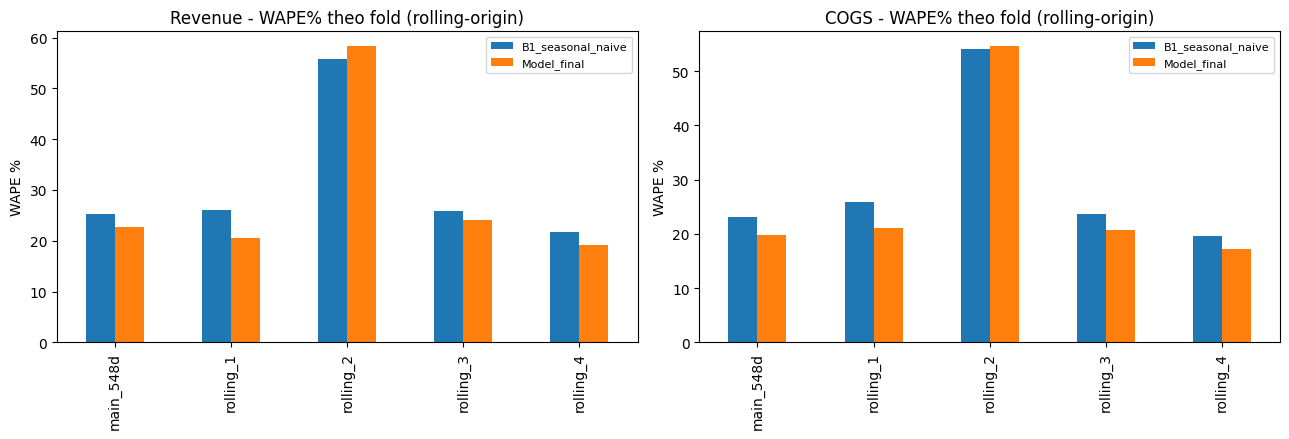

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fold_order = [f["label"] for f in folds]
for ax, target in zip(axes, features.TARGETS):
    sub = cmp[cmp["target"] == target]
    piv = sub.pivot(index="fold", columns="model_label", values="WAPE").reindex(fold_order)
    piv.plot(kind="bar", ax=ax)
    ax.set_title(f"{target} - WAPE% theo fold (rolling-origin)")
    ax.set_ylabel("WAPE %")
    ax.set_xlabel("")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Đọc chart:** cả B1 lẫn Model đều tệ hẳn ở fold `rolling_2` (2018-07 →
2019-12, đúng giai đoạn sốc cấu trúc break 2019) — giới hạn dữ liệu, không
phải lỗi model cụ thể (khớp phát hiện Phase 7/8 gốc). Fold `main_548d` (mốc
chính thức) và các fold còn lại: Model thắng B1 rõ ràng.

## 6. Feature importance — production fit (`models.fit_all`, FINAL_CONFIG, SEED=42)

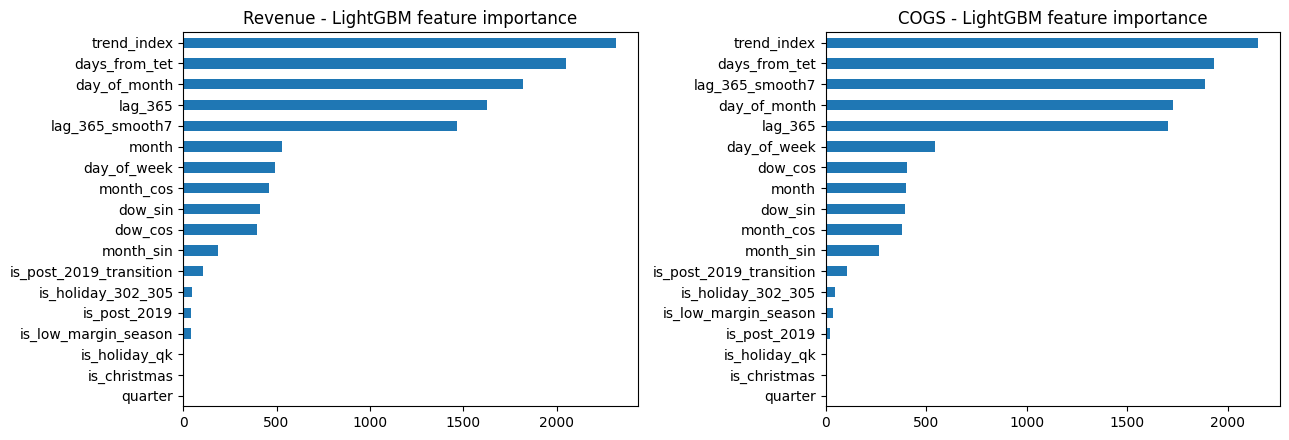

Revenue top-5 feature importance:
trend_index        2318
days_from_tet      2053
day_of_month       1821
lag_365            1625
lag_365_smooth7    1465

COGS top-5 feature importance:
trend_index        2153
days_from_tet      1934
lag_365_smooth7    1885
day_of_month       1730
lag_365            1702



In [11]:
forecasters = models.fit_all(train)  # FINAL_CONFIG, fit that (deterministic, SEED=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, target in zip(axes, features.TARGETS):
    imp = forecasters[target].feature_importance.sort_values(ascending=True)
    imp.plot(kind="barh", ax=ax)
    ax.set_title(f"{target} - LightGBM feature importance")
plt.tight_layout()
plt.show()

for target in features.TARGETS:
    top5 = forecasters[target].feature_importance.sort_values(ascending=False).head(5)
    print(f"{target} top-5 feature importance:")
    print(top5.to_string())
    print()

## 7. Submission — `datathon.submission` (fit full train 2012-2022 + forecast 548 ngày thật)

Fit lại `FINAL_CONFIG` trên TOÀN BỘ `features_train` (không phải leakage —
horizon 2023-2024 không có ground-truth nào bị lộ), forecast 548 ngày qua
`features.recursive_forecast` (đệ quy — phần đuôi horizon >365 ngày tra lag
từ CHÍNH dự đoán model đã sinh cho ngày < d, KHÔNG bao giờ đọc actual/dự đoán
ngày ≥ d).

In [12]:
t0 = time.time()
sub = submission.build_submission()  # goi fit_all + predict_all + validate_submission that
print(f"build_submission elapsed: {time.time() - t0:.1f}s")
print(sub.shape)
sub.head()

build_submission elapsed: 7.5s
(548, 3)


,Date,Revenue,COGS
0,2023-01-01,2770945.66,2747236.58
1,2023-01-02,2179708.03,2108512.05
2,2023-01-03,949003.95,898342.74
3,2023-01-04,1152879.38,1078578.95
4,2023-01-05,944637.68,794175.58


In [13]:
sub.tail()

,Date,Revenue,COGS
543,2024-06-27,5196673.87,4990675.59
544,2024-06-28,5563825.86,5394439.91
545,2024-06-29,5148692.29,4742152.96
546,2024-06-30,4881406.64,4811214.45
547,2024-07-01,4752137.98,4404047.71


In [14]:
checks = submission.validate_submission(sub)
for name, ok, detail in checks:
    status = "PASS" if ok else "FAIL"
    print(f"[{status}] {name}  {detail}")
assert all(ok for _, ok, _ in checks), "submission format FAIL"
print("\nsubmission format: TAT CA CHECK PASS.")

[PASS] columns == [Date,Revenue,COGS]  got ['Date', 'Revenue', 'COGS']
[PASS] row count == 548  rows=548
[PASS] row count == sample  sub=548 sample=548
[PASS] all Date parse YYYY-MM-DD  unparseable=0
[PASS] no duplicate dates  
[PASS] date order == sample  elementwise date equality
[PASS] 0 NaN Revenue/COGS  nan=0
[PASS] 0 negative values  neg=0

submission format: TAT CA CHECK PASS.


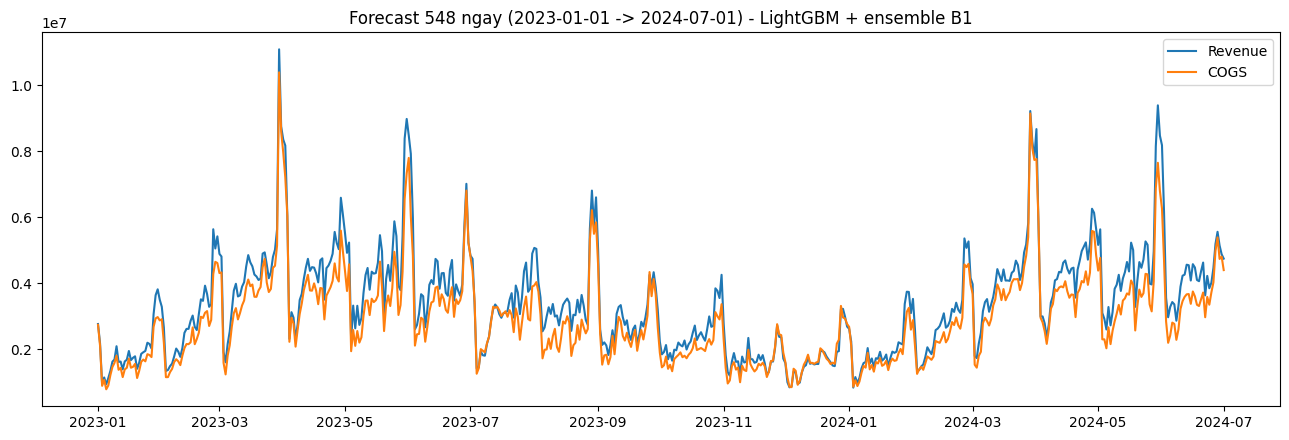

In [15]:
fig, ax = plt.subplots(figsize=(13, 4.5))
plot_df = sub.assign(Date=pd.to_datetime(sub["Date"]))
ax.plot(plot_df["Date"], plot_df["Revenue"], label="Revenue")
ax.plot(plot_df["Date"], plot_df["COGS"], label="COGS")
ax.set_title("Forecast 548 ngay (2023-01-01 -> 2024-07-01) - LightGBM + ensemble B1")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
import tempfile

out_path = Path(tempfile.gettempdir()) / "datathon_forecast_548.csv"
sub.to_csv(out_path, index=False)
print("Ghi (tam, khong commit):", out_path)

Ghi (tam, khong commit): /var/folders/t9/tstf90y13wd9p_7gc7pf9htr0000gp/T/datathon_forecast_548.csv


## 8. REGRESSION CHECK — `forecast_548` vs committed baseline

Baseline "sự thật" chốt tại Phase 9, path theo quy ước `RESTRUCTURE_AGENTS.md`:
`docs/analysis/phase9_validation/committed_baseline/forecast_548.committed.csv`.
File này đã được **cherry-pick vào nhánh `chore/restructure-lakehouse`** từ
`feat/phase8-model` (byte-identical, verify SHA — xem
`.process_status/cherrypick_phase8_9.md`), không còn phụ thuộc `git show`
sang commit/nhánh khác.

Cell dưới: đọc thẳng path local, `assert` file tồn tại (fail rõ ràng, không
fallback ngầm) — nếu ai xoá `docs/analysis/phase9_validation/` sẽ báo lỗi
ngay tại đây thay vì âm thầm gọi `git show`.


In [17]:
LOCAL_BASELINE = (
    PROJECT_ROOT / "docs" / "analysis" / "phase9_validation" / "committed_baseline"
    / "forecast_548.committed.csv"
)
assert LOCAL_BASELINE.exists(), (
    f"Thieu baseline: {LOCAL_BASELINE}. Xem docs/analysis/phase9_validation/ "
    "(cherry-pick tu feat/phase8-model, .process_status/cherrypick_phase8_9.md)."
)
baseline = pd.read_csv(LOCAL_BASELINE)
baseline_source = str(LOCAL_BASELINE)

print("Baseline nguon:", baseline_source)
print("Baseline shape:", baseline.shape)
baseline.head(2)


Baseline nguon: /Users/lhoanghai_/Documents/Study/Dự án datathon2026/docs/analysis/phase9_validation/committed_baseline/forecast_548.committed.csv
Baseline shape: (548, 3)


,Date,Revenue,COGS
0,2023-01-01,2770945.66,2747236.58
1,2023-01-02,2179708.03,2108512.05


In [18]:
gen = sub.copy()
assert list(gen.columns) == list(baseline.columns) == ["Date", "Revenue", "COGS"], "cot khong khop"
assert len(gen) == len(baseline) == 548, f"so dong khong khop: gen={len(gen)} baseline={len(baseline)}"
assert (gen["Date"].to_numpy() == baseline["Date"].to_numpy()).all(), "Date lech thu tu/gia tri"

diff = gen[["Revenue", "COGS"]].to_numpy(dtype=float) - baseline[["Revenue", "COGS"]].to_numpy(dtype=float)
max_abs_diff = float(np.abs(diff).max())
n_diff_gt_1cent = int((np.abs(diff) > 0.01).sum())
n_diff_nonzero = int((np.abs(diff) > 0).sum())

print(f"max abs diff (Revenue+COGS, VND) = {max_abs_diff}")
print(f"n_diff > 0.01              = {n_diff_gt_1cent}")
print(f"n_diff > 0 (bat ky sai lech)= {n_diff_nonzero}")

assert max_abs_diff == 0.0, f"REGRESSION FAIL - lech baseline, max abs diff = {max_abs_diff}"
print("\nREGRESSION PASS - forecast_548 khop committed baseline BYTE-IDENTICAL (max abs diff = 0.0, 548 dong).")

max abs diff (Revenue+COGS, VND) = 0.0
n_diff > 0.01              = 0
n_diff > 0 (bat ky sai lech)= 0

REGRESSION PASS - forecast_548 khop committed baseline BYTE-IDENTICAL (max abs diff = 0.0, 548 dong).


## 9. Hạn chế & rủi ro (leakage, drift, bias)

1. **Không leakage (audit ở M4b + Phase 9 gốc):** calendar feature chỉ hàm số
   của chính ngày d hoặc hằng số neo cố định; `lag_365`/`lag_365_smooth7` luôn
   tra `d-365(±tol)` — luôn < d; forecast 548 ngày dùng `recursive_forecast`
   đệ quy (`hist` chỉ cập nhật bằng dự đoán CHÍNH model đã sinh cho ngày < d).
2. **Compounding error phần đuôi horizon** (>365 ngày, lag tra từ dự đoán
   chain thay vì actual): Phase 9 gốc đã đo riêng — đuôi (366-548) KHÔNG suy
   giảm (còn tốt hơn đầu, Rev −3.74 / COGS −0.84 điểm WAPE) → rủi ro thấp hơn
   lo ngại ban đầu, nhưng notebook này KHÔNG re-verify số đó (chỉ port lại kết
   luận Phase 9, chưa tách lại WAPE 1-365 vs 366-548 trên nhánh này).
3. **`trend_index` ngoại suy — tree chặn phẳng ở leaf cuối** (100% ngày
   forecast > max `trend_index` train, theo phát hiện SHAP Phase 9) → đóng
   góp gần hằng số cho toàn horizon — rủi ro **under-forecast** nếu nền
   2023-2024 thật tăng vượt lịch sử train.
4. **Fold `rolling_2` (thẳng qua break cấu trúc 2019) — MỌI model (kể cả B1)
   đều kém hẳn** (xem WAPE mục 5, chart mục 5) — nếu 2023-2024 có sốc cấu
   trúc tương tự, mọi model train trên 2012-2022 có rủi ro tương tự. Giới hạn
   dữ liệu, không riêng model này.
5. **Không có ground-truth 2023-2024** — mọi WAPE trong notebook đến từ
   holdout nội bộ (2012-2022); độ tin cậy áp dụng cho horizon thật phụ thuộc
   giả định "cơ chế sinh dữ liệu 2023-2024 tương tự lịch sử", CHƯA kiểm chứng.
6. **REGRESSION CHECK (mục 8) đã hết phụ thuộc `git show`** — baseline
   cherry-pick vào `docs/analysis/phase9_validation/` (byte-identical verify
   SHA, xem `.process_status/cherrypick_phase8_9.md`). Rủi ro mất nguồn đối
   chiếu nếu `feat/phase8-model` bị xoá **đã đóng**.
7. **LightGBM không pin version trong `pyproject.toml`** — môi trường khác
   (VD Colab) có thể chạy bản LightGBM khác máy port gốc, lý thuyết có thể
   gây sai khác số học cực nhỏ dù cùng SEED (chưa quan sát thấy trên máy chạy
   notebook này — xem PASS mục 8).

## 10. Bước tiếp theo

- **Ship:** đề bài là nộp file (không phải serve API) — mục 7 đã sinh + tự
  validate `submission.csv` đúng format. Nên lưu `forecast_548.csv` + snapshot
  input feature mỗi lần nộp chính thức để tái lập được (traceability).
- **Khi có actual 2023 thật (dù 1 phần):** retrain theo lịch (khuyến nghị
  Phase 8: mỗi quý) + theo dõi WAPE rolling trên dữ liệu mới — phát hiện sớm
  nếu cơ chế sinh dữ liệu đổi khác so với 2012-2022 (đặc biệt vùng
  `trend_index` ngoại suy, mục 9.3).
- **Nếu WAPE thực tế xấu hơn nhiều so với backtest:** ưu tiên kiểm sốc cấu
  trúc kiểu `rolling_2` trước (mục 9.4) — GradientBoosting đã được Phase 8 xác
  định là phương án dự phòng ổn định hơn qua break, có thể swap
  `models.FINAL_CONFIG` sang GradientBoosting nếu cần.
- **Đã xong:** cherry-pick `docs/analysis/phase8_model` + `phase9_validation`
  từ `feat/phase8-model` (byte-identical, 18/18 file SHA khớp) — xem
  `.process_status/cherrypick_phase8_9.md`. Mục 8 (REGRESSION CHECK) nay đọc
  local, hết phụ thuộc `git show`.